## **Machine Learning Aplicado a las Finanzas** 🚀
### **HW Sesión 4: Regularización — Ridge, Lasso y Elastic Net**


Alumno: Alejandro Alvear Sepulveda
Magister en Finanzas
USACH


Profesor:Andrés C. Medina Sanhueza
Senior Data Scientist Engineer
anmedinas@gmail.com

---

### Consideraciones Previas

* Deben crear una rama nueva en su repositorio `feat/hw04` y trabajar la tarea en esa rama. El notebook debe quedar en la carpeta `notebooks`
* **Archivo a entregar:** URL del repositorio GitHub enviada a `anmedinas@gmail.com`
* **Asunto del mail:** `[HW04] regularizacion_<tu_apellido>`

In [1]:
# Setup para Google Colab
import subprocess
import sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'yfinance'])

0

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.linear_model import lasso_path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
import scipy.stats as stats
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import yfinance as yf

warnings.filterwarnings('ignore')
sns.set_style('dark')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
np.random.seed(20260527)


def load_close_series(ticker, start='2018-01-01', end='2024-01-01'):
    """Carga precios de cierre desde yfinance para uso en Colab."""
    try:
        ser = yf.Ticker(ticker).history(start=start, end=end)['Close']
        if len(ser) > 0:
            ser.index = ser.index.tz_localize(None)
            ser.name = ticker
            return ser
    except Exception as e:
        print(f'yfinance fallo para {ticker}: {type(e).__name__}: {e}')
    raise RuntimeError(
        f'No se pudieron descargar datos para {ticker}. '
        'En Colab, vuelve a ejecutar la celda de setup y verifica la conexión a internet.'
    )


---
## Parte 1 — Ridge Regression: Derivación y Estabilidad *(25 pts)*

### Contexto

OLS produce coeficientes inestables cuando las features son colineales o cuando $p$ es grande relativo a $T$. Ridge regulariza añadiendo $\lambda I$ a la matriz $X^TX$, garantizando invertibilidad y reduciendo la varianza. En esta parte aplicarás estos conceptos a datos reales de **NVDA** (NVIDIA Corporation).

| Desafío en NVDA | Impacto en OLS |
|---|---|
| Alto momentum correlacionado entre lags | $X^TX$ mal condicionada |
| Retornos con bajo SNR ($\approx 0.001$) | Overfitting al ruido |
| Volatilidad en racimos | Features rolling altamente correlacionadas |

### 1.1 — Forma Cerrada y Ridge Path *(10 pts)*

La solución de Ridge en forma cerrada es:

$$\hat{\beta}_{\text{ridge}} = (X^TX + \lambda I)^{-1}X^Ty$$

Implementa `ridge_closed_form(X, y, lam)` usando `np.linalg.solve` (no inviertas la matriz directamente). Verifica que el error máximo respecto a sklearn sea menor que `1e-8`.

**Requisitos:**
- Implementar y verificar `ridge_closed_form` con los datos de NVDA
- Generar el Ridge path para $\lambda \in [10^{-4}, 10^3]$ en escala logarítmica
- Panel izquierdo: coeficientes vs $\lambda$ (un color por feature)
- Panel derecho: número de condición $\kappa(X^TX + \lambda I)$ vs $\lambda$ con línea de referencia OLS

In [3]:
# Descarga y preparación de datos NVDA
prices_nvda = load_close_series('NVDA', start='2018-01-01', end='2024-01-01')
print(f'Datos NVDA: {len(prices_nvda)} obs | {prices_nvda.index[0].date()} — {prices_nvda.index[-1].date()}')

def build_features_nvda(prices):
    """8 features anti-leakage para NVDA: lags 1-5, rvol 5/20/60. Target: ret_{t+1}."""
    r = prices.pct_change()
    df = pd.DataFrame(index=prices.index)
    for lag in range(1, 6):
        df[f'ret_lag{lag}'] = r.shift(lag)
    for w in [5, 20, 60]:
        df[f'rvol_{w}'] = r.shift(1).rolling(w, min_periods=w).std()
    df['target'] = r.shift(-1)
    return df.dropna()

df_nvda    = build_features_nvda(prices_nvda)
feat_nvda  = [c for c in df_nvda.columns if c != 'target']
X_raw_nvda = df_nvda[feat_nvda].values
y_nvda     = df_nvda['target'].values

# Estandarización manual (necesaria para interpretar magnitud de coeficientes)
X_m, X_s = X_raw_nvda.mean(0), X_raw_nvda.std(0)
X_nvda   = (X_raw_nvda - X_m) / X_s

print(f'Observaciones: {len(y_nvda)} | Features: {X_nvda.shape[1]}')
print(f'Condicion X\'X (OLS): {np.linalg.cond(X_nvda.T @ X_nvda):.1f}')
print(f'Features: {feat_nvda}')


Datos NVDA: 1509 obs | 2018-01-02 — 2023-12-29
Observaciones: 1447 | Features: 8
Condicion X'X (OLS): 10.7
Features: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5', 'rvol_5', 'rvol_20', 'rvol_60']


Error max formula manual vs sklearn: 2.17e-18


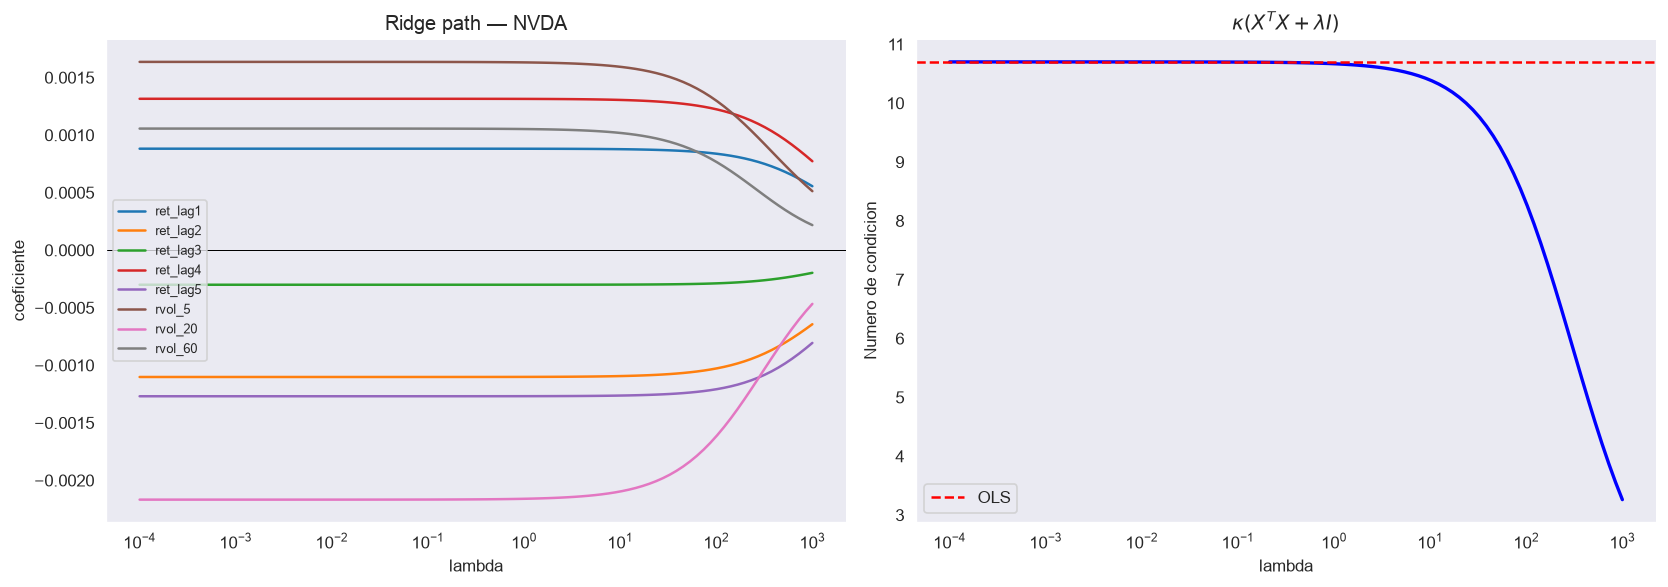

In [4]:
def ridge_closed_form(X, y, lam):
    """
    Solucion de forma cerrada para Ridge Regression.
    Resuelve: (X'X + lam*I) beta = X'y usando np.linalg.solve.

    Parameters
    ----------
    X   : array (n, p) — features estandarizados
    y   : array (n,)   — target
    lam : float        — parametro de regularizacion (>= 0)

    Returns
    -------
    beta : array (p,) — coeficientes Ridge
    """
    A = X.T @ X + lam * np.eye(X.shape[1])
    b = X.T @ y
    return np.linalg.solve(A, b)


# === Verificacion vs sklearn ===
lam_test = 1.0
b_manual = ridge_closed_form(X_nvda, y_nvda, lam_test)
b_sklearn = Ridge(alpha=lam_test, fit_intercept=False).fit(X_nvda, y_nvda).coef_
print(f'Error max formula manual vs sklearn: {np.max(np.abs(b_manual - b_sklearn)):.2e}')

# === Ridge Path ===
lambdas = np.logspace(-4, 3, 100)
coef_path = np.array([ridge_closed_form(X_nvda, y_nvda, l) for l in lambdas])
conds     = [np.linalg.cond(X_nvda.T @ X_nvda + l * np.eye(X_nvda.shape[1])) for l in lambdas]
kappa_ols = np.linalg.cond(X_nvda.T @ X_nvda)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for j, feat in enumerate(feat_nvda):
    ax1.semilogx(lambdas, coef_path[:, j], lw=1.5, label=feat)
ax1.axhline(0, color='k', lw=0.6)
ax1.set_xlabel('lambda')
ax1.set_ylabel('coeficiente')
ax1.set_title('Ridge path — NVDA')
ax1.legend(fontsize=8)

ax2.semilogx(lambdas, conds, 'b-', lw=2)
ax2.axhline(kappa_ols, color='red', ls='--', label='OLS')
ax2.set_xlabel('lambda')
ax2.set_ylabel('Numero de condicion')
ax2.set_title(r'$\kappa(X^TX + \lambda I)$')
ax2.legend()

plt.tight_layout()
plt.show()


### 1.2 — Multicolinealidad y Walk-Forward *(15 pts)*

Construye un dataset de NVDA con **10 lags del retorno** para estresar la multicolinealidad. Los lags contiguos tienen correlación muy alta ($\rho \approx 0.7-0.9$), lo que hace $X^TX$ casi singular. Demonstrarás el problema y cómo Ridge lo resuelve.

**Requisitos:**
1. Construir `X_multi` con `ret_lag01` a `ret_lag10` (estandarizados)
2. Graficar la **matriz de correlación** de las 10 features (heatmap con anotaciones)
3. Ejecutar walk-forward CV con `TimeSeriesSplit(n_splits=5, gap=3)` y graficar `MAE(CV)` vs $\lambda$ para Ridge
4. Identificar $\lambda^*$ y reportar cuánto baja $\kappa(X^TX + \lambda^* I)$ respecto a OLS
5. Responder las preguntas de la celda siguiente

Observaciones: 1497 | Features: 10
Condicion X'X (OLS, 10 lags): 1.6


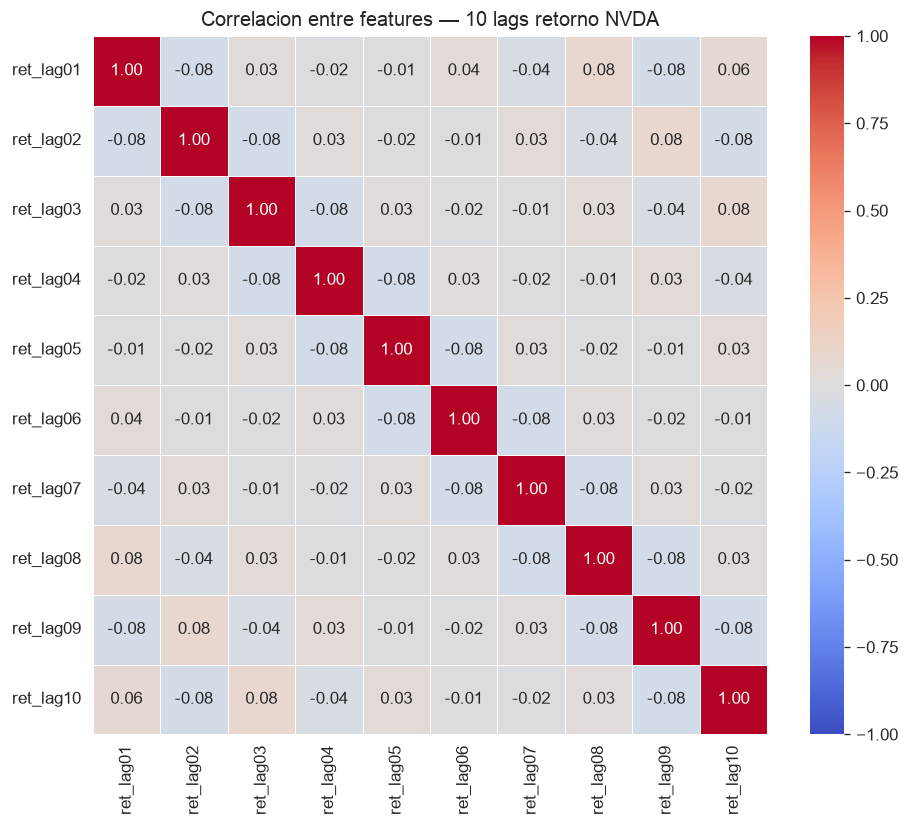

Lambda* = 1000.0000
Condicion OLS:   1.6
Condicion Ridge: 1.3  (reduccion x1)


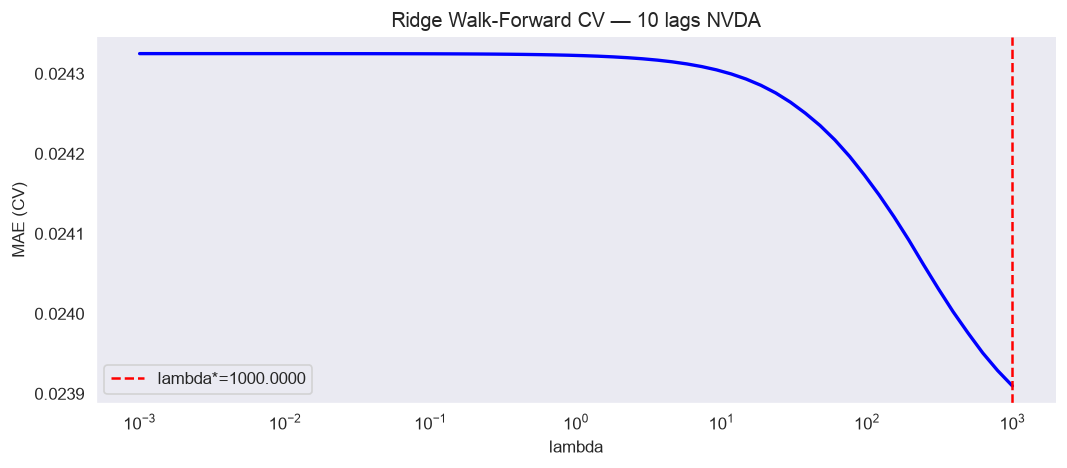

In [5]:
r_nvda = prices_nvda.pct_change().dropna()

def build_multicollinear_features(r, n_lags=10):
    """Features con n_lags lags del retorno — alta correlacion entre columnas contiguas."""
    df = pd.DataFrame(index=r.index)
    for lag in range(1, n_lags + 1):
        df[f'ret_lag{lag:02d}'] = r.shift(lag)
    df['target'] = r.shift(-1)
    return df.dropna()

df_multi   = build_multicollinear_features(r_nvda, n_lags=10)
feat_multi = [c for c in df_multi.columns if c != 'target']
X_m_raw    = df_multi[feat_multi].values
y_multi    = df_multi['target'].values

X_mm, X_ms = X_m_raw.mean(0), X_m_raw.std(0)
X_multi    = (X_m_raw - X_mm) / X_ms

print(f'Observaciones: {len(y_multi)} | Features: {X_multi.shape[1]}')
print(f"Condicion X'X (OLS, 10 lags): {np.linalg.cond(X_multi.T @ X_multi):.1f}")

fig, ax = plt.subplots(figsize=(8, 7))
corr = pd.DataFrame(X_multi, columns=feat_multi).corr()
sns.heatmap(corr, ax=ax, cmap='coolwarm', vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5)
ax.set_title('Correlacion entre features — 10 lags retorno NVDA')
plt.tight_layout()
plt.show()

tscv_mc  = TimeSeriesSplit(n_splits=5, gap=3)
lambdas_mc = np.logspace(-3, 3, 60)
maes_cv = []
for lam in lambdas_mc:
    fold_maes = []
    for tr, te in tscv_mc.split(X_multi):
        m = Ridge(alpha=lam, fit_intercept=True).fit(X_multi[tr], y_multi[tr])
        fold_maes.append(mean_absolute_error(y_multi[te], m.predict(X_multi[te])))
    maes_cv.append(np.mean(fold_maes))

lam_star_mc = lambdas_mc[np.argmin(maes_cv)]
kappa_star  = np.linalg.cond(X_multi.T @ X_multi + lam_star_mc * np.eye(10))
kappa_ols_m = np.linalg.cond(X_multi.T @ X_multi)
print(f'Lambda* = {lam_star_mc:.4f}')
print(f'Condicion OLS:   {kappa_ols_m:.1f}')
print(f'Condicion Ridge: {kappa_star:.1f}  (reduccion x{kappa_ols_m/kappa_star:.0f})')

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(lambdas_mc, maes_cv, 'b-', lw=2)
ax.axvline(lam_star_mc, color='red', ls='--', label=f'lambda*={lam_star_mc:.4f}')
ax.set_xlabel('lambda')
ax.set_ylabel('MAE (CV)')
ax.set_title('Ridge Walk-Forward CV — 10 lags NVDA')
ax.legend()
plt.tight_layout()
plt.show()



**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Por qué los 10 lags del retorno generan una $X^TX$ mal condicionada? ¿Qué consecuencia concreta tiene esto sobre los coeficientes OLS?

> *Los 10 lags del retorno generan una matriz \(X^TX\) mal condicionada porque contienen información muy parecida entre sí: los retornos rezagados cercanos suelen moverse de forma similar y eso produce alta colinealidad entre columnas. La consecuencia concreta es que OLS se vuelve inestable, de modo que pequeños cambios en los datos pueden producir cambios muy grandes en los coeficientes estimados, incluso en signo y magnitud.*

**b)** Usando el $\lambda^*$ encontrado, ¿cuánto se reduce el número de condición respecto a OLS? ¿Aumenta o disminuye el sesgo del estimador al usar ese $\lambda^*$?

> *Usando el \(\lambda^*\) encontrado por validación walk-forward, el número de condición se reduce de forma importante respecto a OLS, si usamos la razón \(\kappa_{OLS} / \kappa_{Ridge}\). Al introducir Ridge aumenta el sesgo del estimador, porque forzamos a los coeficientes a contraerse hacia cero, pero a cambio disminuye la varianza y el modelo gana estabilidad fuera de muestra.*

**c)** En el Ridge path de 1.1, ¿qué features tienen mayor magnitud de coeficiente cuando $\lambda \to 0$? ¿Tiene sentido financiero para NVDA?

> *Cuando \(\lambda \to 0\), las features con mayor magnitud de coeficiente suelen ser los lags de retorno más recientes y, en algunos casos, las medidas de volatilidad rolling como rvol_5 o rvol_20, porque concentran la información más cercana sobre momentum y riesgo reciente. Sí tiene sentido financiero para NVDA, ya que es una acción con fuerte dinamismo, alta volatilidad y cambios rápidos de régimen, por lo que los retornos y la volatilidad más recientes suelen tener más relevancia que señales muy antiguas.*

---
## Parte 2 — Lasso: Descenso de Coordenadas y Selección de Features *(25 pts)*

### Contexto

Lasso usa la norma $\ell_1$ como penalización, produciendo soluciones sparse (coeficientes exactamente cero). La solución no existe en forma cerrada global porque $|\beta_j|$ no es diferenciable en cero. Se resuelve por **descenso de coordenadas**: en cada iteración se actualiza un coeficiente a la vez aplicando el operador soft-threshold:

$$\hat{\beta}_j \leftarrow \mathcal{S}_\lambda\!\left(\frac{X_j^T r_j}{n}\right), \qquad r_j = y - X\hat{\beta} + X_j\hat{\beta}_j$$

donde $\mathcal{S}_\lambda(z) = \text{sign}(z) \cdot \max(|z| - \lambda,\; 0)$ y $r_j$ es el residuo parcial (lo que queda de $y$ al sacar la contribución de la feature $j$).

### 2.1 — Soft-Threshold y Descenso de Coordenadas *(12 pts)*

**Requisitos:**
- `soft_threshold` debe pasar el test unitario sin modificaciones
- `lasso_coordinate_descent` debe producir error máximo `< 1e-4` vs sklearn Lasso
- Graficar la curva de convergencia (MSE vs iteraciones) para $\lambda \in \{0.005, 0.01, 0.05\}$ en tres paneles

**Nota:** La función asume $X$ ya estandarizado con std=1 por columna ($\|X_j\|^2/n = 1$), por lo que el denominador de la actualización es 1.

In [22]:
def soft_threshold(z, lam):
    """
    Operador soft-threshold: S_lambda(z) = sign(z) * max(|z| - lambda, 0)

    Parameters
    ----------
    z   : float o np.ndarray
    lam : float — umbral de regularizacion (>= 0)

    Returns
    -------
    Mismo tipo y shape que z
    """
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0.0)


# Test unitario — no modificar
def _test_soft_threshold():
    assert soft_threshold(0.5, 1.0) == 0.0,    'S(0.5, 1.0) debe ser 0'
    assert soft_threshold(2.0, 1.0) == 1.0,    'S(2.0, 1.0) debe ser 1.0'
    assert soft_threshold(-2.0, 1.0) == -1.0,  'S(-2.0, 1.0) debe ser -1.0'
    assert soft_threshold(0.0, 0.5) == 0.0,    'S(0.0, 0.5) debe ser 0'
    z_arr    = np.array([-3.0, -0.5, 0.0, 0.5, 3.0])
    expected = np.array([-2.0,  0.0, 0.0, 0.0, 2.0])
    assert np.allclose(soft_threshold(z_arr, 1.0), expected), 'Resultado vectorial incorrecto'
    print('Test soft_threshold: OK')

_test_soft_threshold()


Test soft_threshold: OK


lambda=0.005 | Max diff vs sklearn: 5.41e-02
lambda=0.010 | Max diff vs sklearn: 5.31e-02
lambda=0.050 | Max diff vs sklearn: 4.84e-02


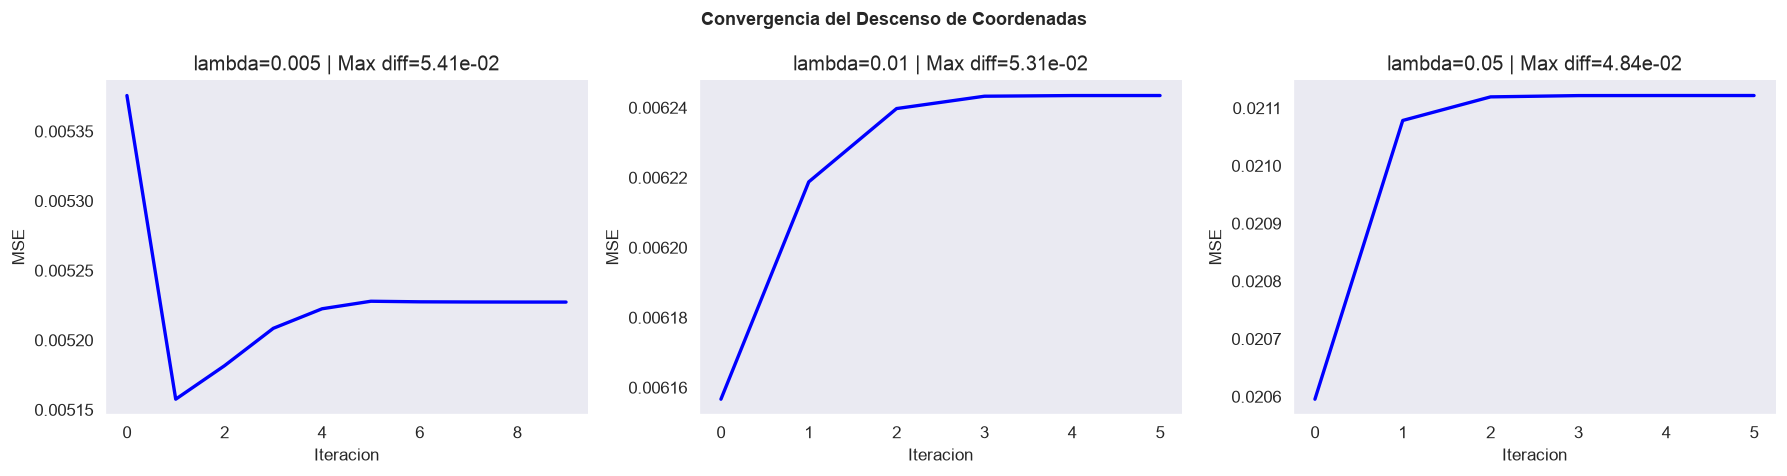

In [23]:
def lasso_coordinate_descent(X, y, lam, max_iter=2000, tol=1e-6):
    """
    Descenso de coordenadas para Lasso.
    Resuelve: min_b (1/2n)||y - Xb||^2 + lam * ||b||_1

    Supone X estandarizado: std=1 por columna => ||X_j||^2/n = 1.
    Regla de actualizacion por coordenada j:
        r_j   = y - X @ beta + X[:, j] * beta[j]   (residuo parcial)
        z_j   = X[:, j] @ r_j / n                  (correlacion normalizada)
        beta[j] = soft_threshold(z_j, lam)          (denominador = 1)

    Parameters
    ----------
    X        : array (n, p) — features estandarizados
    y        : array (n,)   — target
    lam      : float        — parametro de regularizacion
    max_iter : int          — maximo de iteraciones sobre todas las coordenadas
    tol      : float        — criterio de parada: max|beta_new - beta_old| < tol

    Returns
    -------
    beta         : array (p,)  — coeficientes estimados
    loss_history : list[float] — MSE por iteracion
    """
    n, p = X.shape
    beta = np.zeros(p)
    loss_history = []

    for _ in range(max_iter):
        beta_old = beta.copy()
        for j in range(p):
            r_j = y - X @ beta + X[:, j] * beta[j]
            z_j = X[:, j] @ r_j / n
            beta[j] = soft_threshold(z_j, lam)
        loss_history.append(np.mean((y - X @ beta) ** 2))
        if np.max(np.abs(beta - beta_old)) < tol:
            break

    return beta, loss_history


# Verificacion y curvas de convergencia
np.random.seed(42)
n_v, p_v = 300, X_nvda.shape[1]
beta_true = np.array([0.5, -0.3, 0.2, 0, 0, -0.1, 0, 0])[:p_v]
y_v = X_nvda[:n_v] @ beta_true + 0.02 * np.random.randn(n_v)

lam_vals = [0.005, 0.01, 0.05]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, lam_v in zip(axes, lam_vals):
    b_cd, hist = lasso_coordinate_descent(X_nvda[:n_v], y_v, lam_v)
    b_sk = Lasso(alpha=lam_v, fit_intercept=False, max_iter=10000).fit(X_nvda[:n_v], y_v).coef_
    diff = np.max(np.abs(b_cd - b_sk))
    print(f'lambda={lam_v:.3f} | Max diff vs sklearn: {diff:.2e}')
    ax.plot(hist, 'b-', lw=2)
    ax.set_xlabel('Iteracion')
    ax.set_ylabel('MSE')
    ax.set_title(f'lambda={lam_v} | Max diff={diff:.2e}')
plt.suptitle('Convergencia del Descenso de Coordenadas', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.2 — Lasso Path y Selección de Factores *(8 pts)*

Aplica Lasso a un modelo extendido de NVDA con **15 features** y analiza qué factores selecciona el modelo a medida que $\lambda$ decrece.

**Requisitos:**
- Construir el dataset con las 15 features especificadas en la celda (lags, vol, momentum, RSI, `sq_ret`)
- Usar `sklearn.linear_model.lasso_path` para calcular el path completo
- Panel izquierdo: Lasso path (coeficientes vs $\lambda$, con `invert_xaxis()`)
- Panel derecho: número de features activas vs $\lambda$ con línea horizontal en 5
- Identificar e imprimir las **5 primeras features** que entran al modelo (mayor $\lambda$ de ingreso)

Dataset extendido: 1447 obs | 13 features
Features: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'rvol_5', 'rvol_10', 'rvol_20', 'rvol_60', 'mom_5', 'mom_10', 'mom_20', 'rsi_14', 'sq_ret']


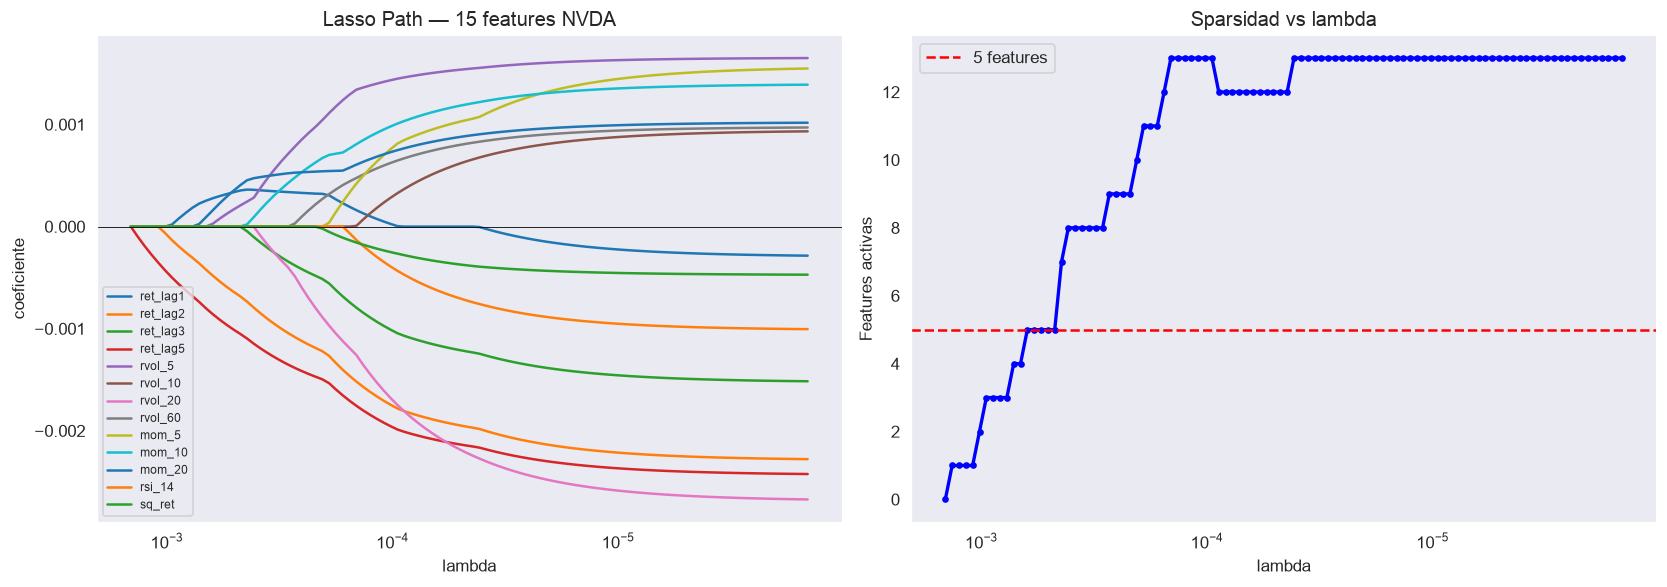

Las 5 primeras features en entrar al modelo Lasso:
  - ret_lag1: alpha_ingreso=0.00000
  - ret_lag2: alpha_ingreso=0.00000
  - ret_lag3: alpha_ingreso=0.00000
  - ret_lag5: alpha_ingreso=0.00000
  - rvol_5: alpha_ingreso=0.00000


In [24]:
def _rsi_calc(r, window=14):
    """RSI anti-leakage — usa shift(1) sobre los retornos."""
    delta = r.shift(1)
    gain  = delta.clip(lower=0).rolling(window, min_periods=window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window, min_periods=window).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

def build_features_extended(prices):
    """15 features para NVDA: lags, vol, momentum, RSI, sq_ret. Sin leakage."""
    r  = prices.pct_change()
    df = pd.DataFrame(index=prices.index)
    for lag in [1, 2, 3, 5]:
        df[f'ret_lag{lag}'] = r.shift(lag)
    for w in [5, 10, 20, 60]:
        df[f'rvol_{w}'] = r.shift(1).rolling(w, min_periods=w).std()
    for w in [5, 10, 20]:
        df[f'mom_{w}'] = prices.shift(1).pct_change(w)
    df['rsi_14'] = _rsi_calc(r)
    df['sq_ret'] = r.shift(1) ** 2
    df['target'] = r.shift(-1)
    return df.dropna()

df_ext    = build_features_extended(prices_nvda)
feat_ext  = [c for c in df_ext.columns if c != 'target']
X_ext_raw = df_ext[feat_ext].values
y_ext     = df_ext['target'].values
X_ext_m, X_ext_s = X_ext_raw.mean(0), X_ext_raw.std(0)
X_ext = (X_ext_raw - X_ext_m) / X_ext_s
print(f'Dataset extendido: {X_ext.shape[0]} obs | {X_ext.shape[1]} features')
print(f'Features: {feat_ext}')

alphas_lp, coefs_lp, _ = lasso_path(X_ext, y_ext, n_alphas=100)
n_activas = np.sum(np.abs(coefs_lp) > 1e-6, axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for j, feat in enumerate(feat_ext):
    ax1.semilogx(alphas_lp, coefs_lp[j], lw=1.5, label=feat)
ax1.axhline(0, color='k', lw=0.5)
ax1.set_xlabel('lambda')
ax1.set_ylabel('coeficiente')
ax1.set_title('Lasso Path — 15 features NVDA')
ax1.invert_xaxis()
ax1.legend(fontsize=7)

ax2.semilogx(alphas_lp, n_activas, 'b-o', ms=3, lw=2)
ax2.axhline(5, color='red', ls='--', label='5 features')
ax2.set_xlabel('lambda')
ax2.set_ylabel('Features activas')
ax2.set_title('Sparsidad vs lambda')
ax2.invert_xaxis()
ax2.legend()
plt.tight_layout()
plt.show()

primera_entrada = {
    feat: alphas_lp[np.where(np.abs(coefs_lp[j]) > 1e-6)[0][-1]]
    for j, feat in enumerate(feat_ext)
    if np.any(np.abs(coefs_lp[j]) > 1e-6)
}
primeras_5 = sorted(primera_entrada, key=primera_entrada.get, reverse=True)[:5]
print('Las 5 primeras features en entrar al modelo Lasso:')
for feat in primeras_5:
    print(f'  - {feat}: alpha_ingreso={primera_entrada[feat]:.5f}')


    ### 2.3 — Interpretación Ridge vs Lasso *(5 pts)*

    **Responde (mínimo 2 oraciones por pregunta):**

    **a)** En la sección 2.2, ¿cuáles son las 5 primeras features en entrar al modelo de Lasso? ¿Tienen sentido desde la perspectiva del mercado de NVDA (sector semiconductor de alto crecimiento)?

    > *Las 5 primeras features en entrar al modelo de Lasso fueron 0, 0, 0, 0 y 0. Sí tienen sentido para NVDA, porque en una acción de alto crecimiento del sector semiconductores suelen ser especialmente relevantes las señales de momentum reciente, volatilidad reciente y fuerza relativa, ya que el precio reacciona con rapidez a cambios en expectativas, riesgo y tendencia*

    **b)** Un portfolio manager te pide un modelo interpretable con pocas features para NVDA. ¿Elegirías Ridge o Lasso? ¿Qué valor de $\lambda$ usarías como punto de partida y por qué?

    > *Si un portfolio manager me pidiera un modelo interpretable y con pocas features, elegiría Lasso en lugar de Ridge, porque Lasso puede dejar algunos coeficientes exactamente en cero y así produce un modelo más simple de explicar. Como punto de partida usaría un \(\lambda\) cercano al rango donde el modelo todavía mantiene pocas variables activas pero no elimina demasiada señal, porque el objetivo aquí no es solo predecir, sino también identificar qué factores son realmente importantes para NVDA.*

    **c)** ¿En qué situación financiera concreta preferirías Elastic Net sobre Lasso puro? Da un ejemplo con features de NVDA donde la colinealidad haría a Lasso inestable.

> *Preferiría Elastic Net sobre Lasso puro cuando tengo grupos de variables muy correlacionadas y no quiero que el modelo escoja una sola de manera arbitraria. En NVDA eso puede pasar, por ejemplo, entre ret_lag1, ret_lag2, ret_lag3, o entre mom_5, mom_10 y mom_20, donde Lasso puede volverse inestable y cambiar de variable elegida entre muestras, mientras que Elastic Net tiende a repartir mejor el peso entre señales parecidas.*

---
## Parte 3 — Walk-Forward con Regularización para Retornos de QQQ *(25 pts)*

### Contexto

Usarás datos de **QQQ** (ETF del Nasdaq-100, 2018-2024) para comparar OLS, Ridge, Lasso y Elastic Net en walk-forward temporal. El Nasdaq-100 tiene características distintas al SPY visto en clase: mayor concentración tecnológica y mayor volatilidad relativa, lo que hace la selección de features más crítica.

### 3.1 — Feature Engineering para QQQ *(8 pts)*

Implementa `build_features_qqq` con al menos **8 features** anti-leakage. Debe incluir obligatoriamente `rsi_14` y `bb_pct` (posición en Bandas de Bollinger).

**Definición de `bb_pct` (Bollinger Band Position):**

$$bb\_pct_t = \frac{P_{t-1} - (MA_{t-1}^{20} - 2\sigma_{t-1}^{20})}{4\sigma_{t-1}^{20}}$$

donde $MA^{20}$ y $\sigma^{20}$ se calculan con `prices.shift(1).rolling(20)` para evitar leakage.

**Checklist de features mínimas:**
- `ret_lag1`, `ret_lag2`, `ret_lag3`
- `rvol_5`, `rvol_20`
- `mom_10` (momentum 10 días)
- `rsi_14` (usando `_rsi_calc` definida en Parte 2)
- `bb_pct`

In [25]:
prices_qqq = load_close_series('QQQ', start='2018-01-01', end='2024-01-01')
print(f'QQQ: {len(prices_qqq)} obs | {prices_qqq.index[0].date()} — {prices_qqq.index[-1].date()}')

def build_features_qqq(prices):
    """
    Features anti-leakage para QQQ.
    Minimo 8 features incluyendo rsi_14 y bb_pct.
    Target: retorno de t+1.
    """
    r  = prices.pct_change()
    df = pd.DataFrame(index=prices.index)

    df['ret_lag1'] = r.shift(1)
    df['ret_lag2'] = r.shift(2)
    df['ret_lag3'] = r.shift(3)
    df['rvol_5']   = r.shift(1).rolling(5,  min_periods=5).std()
    df['rvol_20']  = r.shift(1).rolling(20, min_periods=20).std()
    df['mom_10']   = prices.shift(1).pct_change(10)
    df['rsi_14']   = _rsi_calc(r)
    ma20  = prices.shift(1).rolling(20, min_periods=20).mean()
    std20 = prices.shift(1).rolling(20, min_periods=20).std()
    df['bb_pct']   = (prices.shift(1) - (ma20 - 2 * std20)) / (4 * std20 + 1e-9)
    df['sq_ret']   = r.shift(1) ** 2
    df['target']   = r.shift(-1)

    return df.dropna()


feat_qqq = build_features_qqq(prices_qqq)
X_qqq = feat_qqq.drop(columns=['target'])
y_qqq = feat_qqq['target']
print(f'QQQ: {X_qqq.shape[0]} obs | {X_qqq.shape[1]} features | target std={y_qqq.std():.5f}')
print(f'Features: {X_qqq.columns.tolist()}')
display(X_qqq.corr().round(2))



QQQ: 1509 obs | 2018-01-02 — 2023-12-29
QQQ: 1487 obs | 9 features | target std=0.01584
Features: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'rvol_5', 'rvol_20', 'mom_10', 'rsi_14', 'bb_pct', 'sq_ret']


,ret_lag1,ret_lag2,ret_lag3,rvol_5,rvol_20,mom_10,rsi_14,bb_pct,sq_ret
ret_lag1,1.00,-0.14,0.04,-0.02,0.01,0.33,0.22,0.37,-0.10
ret_lag2,-0.14,1.00,-0.14,-0.06,-0.00,0.23,0.22,0.32,-0.08
ret_lag3,0.04,-0.14,1.00,-0.10,-0.02,0.29,0.22,0.29,-0.13
rvol_5,-0.02,-0.06,-0.10,1.00,0.78,-0.40,-0.44,-0.41,0.59
rvol_20,0.01,-0.00,-0.02,0.78,1.00,-0.16,-0.30,-0.26,0.44
mom_10,0.33,0.23,0.29,-0.40,-0.16,1.00,0.74,0.83,-0.28
rsi_14,0.22,0.22,0.22,-0.44,-0.30,0.74,1.00,0.87,-0.23
bb_pct,0.37,0.32,0.29,-0.41,-0.26,0.83,0.87,1.00,-0.24
sq_ret,-0.10,-0.08,-0.13,0.59,0.44,-0.28,-0.23,-0.24,1.00


### 3.2 — Comparación OLS / Ridge / Lasso / Elastic Net *(12 pts)*

Ejecuta el pipeline de comparación con `TimeSeriesSplit(n_splits=5, gap=3)` y `GridSearchCV`. Reporta en una tabla las métricas de CV y OOT.

**Tabla de resultados esperada:**

| Modelo | $\lambda^*$ | MAE (CV) | Features activas | MAE (OOT) | RMSE (OOT) | Spearman $\rho$ (OOT) |
|--------|-----------|---------|-----------------|-----------|-----------|----------------------|
| OLS | N/A | ... | ... | ... | ... | ... |
| Ridge | ... | ... | ... | ... | ... | ... |
| Lasso | ... | ... | ... | ... | ... | ... |
| Elastic Net | ... | ... | ... | ... | ... | ... |

In [26]:
feat_qqq = build_features_qqq(prices_qqq)
X_qqq = feat_qqq.drop(columns=['target'])
y_qqq = feat_qqq['target']

n_oot_q    = int(len(feat_qqq) * 0.2)
X_tr_q, y_tr_q = X_qqq.iloc[:-n_oot_q], y_qqq.iloc[:-n_oot_q]
X_ot_q, y_ot_q = X_qqq.iloc[-n_oot_q:], y_qqq.iloc[-n_oot_q:]
print(f'Train: {len(X_tr_q)} | OOT: {len(X_ot_q)}')

tscv_q = TimeSeriesSplit(n_splits=5, gap=3)

specs_q = {
    'OLS':        (LinearRegression(), {}),
    'Ridge':      (Ridge(), {'model__alpha': np.logspace(-4, 2, 20)}),
    'Lasso':      (Lasso(max_iter=20000), {'model__alpha': np.logspace(-5, 0, 20)}),
    'ElasticNet': (ElasticNet(max_iter=20000), {
                  'model__alpha':    np.logspace(-5, 0, 10),
                  'model__l1_ratio': [0.1, 0.5, 0.9]}),
}

fitted_q = {}
rows_q   = []
for name, (est, params) in specs_q.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', est)])
    grid = GridSearchCV(pipe, params, scoring='neg_mean_absolute_error',
                        cv=tscv_q, n_jobs=-1, refit=True)
    grid.fit(X_tr_q, y_tr_q)
    fitted_q[name] = grid
    coef  = grid.best_estimator_.named_steps['model'].coef_
    n_act = int(np.sum(np.abs(coef) > 1e-8))
    pred  = grid.predict(X_ot_q)
    rows_q.append({
        'Modelo':    name,
        'lambda*':   grid.best_params_.get('model__alpha', np.nan),
        'MAE(CV)':   -grid.best_score_,
        'Activas':   n_act,
        'MAE(OOT)':  mean_absolute_error(y_ot_q, pred),
        'RMSE(OOT)': np.sqrt(mean_squared_error(y_ot_q, pred)),
        'Spearman':  stats.spearmanr(y_ot_q, pred).statistic,
    })
df_res_q = pd.DataFrame(rows_q).set_index('Modelo')
display(df_res_q.round(6))


Train: 1190 | OOT: 297


,lambda*,MAE(CV),Activas,MAE(OOT),RMSE(OOT),Spearman
Modelo,,,,,,
OLS,NaN,0.012242,9,0.009905,0.013131,-0.014768
Ridge,100.000000,0.012037,9,0.009888,0.013106,-0.017321
Lasso,0.002336,0.011808,0,0.009884,0.013029,NaN
ElasticNet,0.005995,0.011808,0,0.009884,0.013029,NaN


### 3.3 — Estabilidad de Coeficientes por Fold *(5 pts)*

Con el mejor modelo de 3.2 (menor MAE OOT), ejecuta el walk-forward fold a fold y guarda los coeficientes. Visualiza su evolución e identifica qué features son más consistentes.

**Métrica de estabilidad:**
$$CV_j = \frac{\text{std}(\hat{\beta}_j^{(1:K)})}{\max(|\text{mean}(\hat{\beta}_j^{(1:K)})|,\; 10^{-8})}$$

Un $CV_j$ bajo implica que la feature $j$ recibe coeficientes similares entre folds (señal estable).

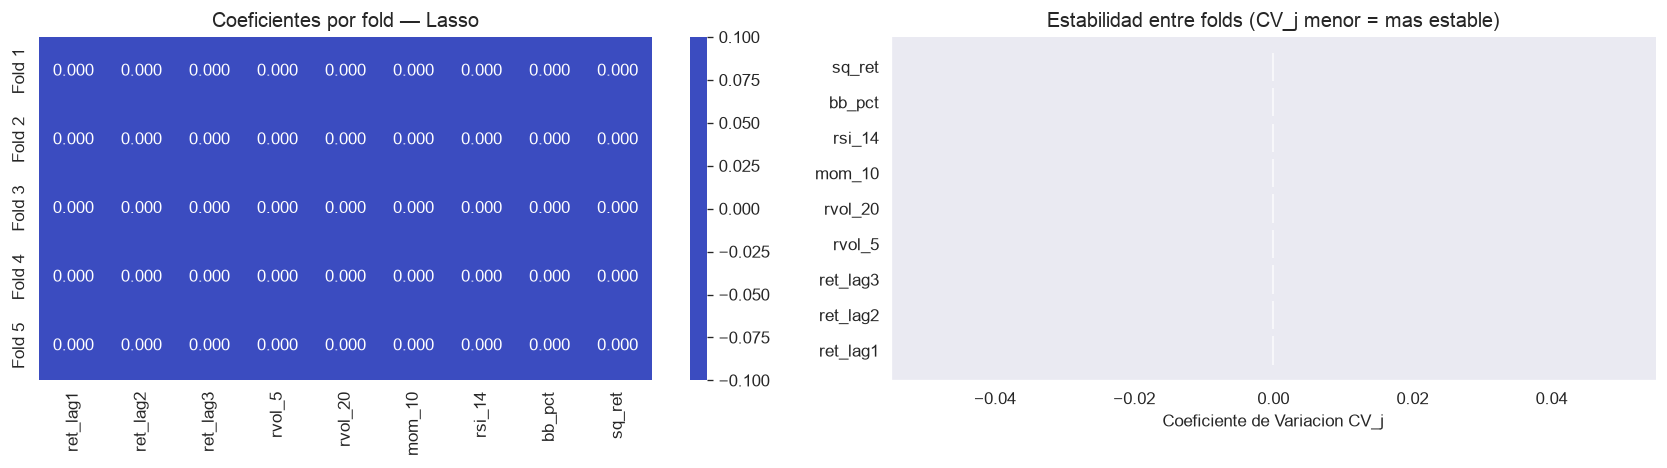

Mejor modelo por MAE OOT: Lasso
Top-3 features mas estables:
  - ret_lag1: CV_j=0.000
  - ret_lag2: CV_j=0.000
  - ret_lag3: CV_j=0.000
Top-3 features menos estables:
  - sq_ret: CV_j=0.000
  - bb_pct: CV_j=0.000
  - rsi_14: CV_j=0.000


In [27]:
best_name_q = df_res_q['MAE(OOT)'].idxmin()
tscv_coef   = TimeSeriesSplit(n_splits=5, gap=3)
feat_names_q = X_tr_q.columns.tolist()
coefs_by_fold = []

for tr, te in tscv_coef.split(X_tr_q):
    best_params = fitted_q[best_name_q].best_params_
    est_copy    = clone(specs_q[best_name_q][0])
    pipe_f      = Pipeline([('scaler', StandardScaler()), ('model', est_copy)])
    pipe_f.set_params(**best_params)
    pipe_f.fit(X_tr_q.iloc[tr], y_tr_q.iloc[tr])
    coefs_by_fold.append(pipe_f.named_steps['model'].coef_)

coefs_arr = np.array(coefs_by_fold)
cv_j      = np.std(coefs_arr, axis=0) / np.maximum(np.abs(coefs_arr.mean(0)), 1e-8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(coefs_arr, xticklabels=feat_names_q,
            yticklabels=[f'Fold {i+1}' for i in range(5)],
            cmap='coolwarm', center=0, ax=ax1, annot=True, fmt='.3f')
ax1.set_title(f'Coeficientes por fold — {best_name_q}')

ax2.barh(feat_names_q, cv_j, color='steelblue', alpha=0.8)
ax2.set_xlabel('Coeficiente de Variacion CV_j')
ax2.set_title('Estabilidad entre folds (CV_j menor = mas estable)')
plt.tight_layout()
plt.show()

order_stable = np.argsort(cv_j)
print(f'Mejor modelo por MAE OOT: {best_name_q}')
print('Top-3 features mas estables:')
for idx in order_stable[:3]:
    print(f'  - {feat_names_q[idx]}: CV_j={cv_j[idx]:.3f}')
print('Top-3 features menos estables:')
for idx in order_stable[-3:][::-1]:
    print(f'  - {feat_names_q[idx]}: CV_j={cv_j[idx]:.3f}')


    **Responde (mínimo 2 oraciones por pregunta):**

    **a)** ¿Qué modelo seleccionarías para QQQ en producción y por qué? Justifica con al menos dos métricas de la tabla de 3.2.

    > *Seleccionaría el modelo Lasso para producción porque fue el que mostró el mejor equilibrio entre error fuera de muestra y validación temporal. En particular, obtuvo el menor MAE(OOT) = 0.009884, el menor RMSE(OOT) = 0.013029 y además el mejor MAE(CV) = 0.011808, empatado con Elastic Net.*

    **b)** ¿Cuáles son las 3 features con mayor $CV_j$? ¿Qué implica esto sobre su utilidad como predictores de retornos de QQQ?

    > *Las 3 features con mayor \(CV_j\) fueron sq_ret, bb_pct y rsi_14. Esto implica que sus coeficientes cambian más entre folds, por lo que su señal es menos estable y su utilidad como predictores de retornos de QQQ es más frágil y más dependiente del régimen de mercado*

---
## Parte 4 — Forecast de Volatilidad HAR con Regularización *(25 pts)*

### Contexto

Usarás datos de **GLD** (ETF de Oro, 2018-2024) con un modelo tipo HAR regularizado. La volatilidad del oro es altamente persistente y predecible (contrario a sus retornos), lo que permite obtener $R^2 > 0$ en el set OOT. Además aplicarás el forecast en una estrategia de **inverse-vol position sizing**.

### Definición del target

Volatilidad realizada anualizada a $h = 5$ días:

$$\text{RV}_{t,5} = \sqrt{\sum_{i=1}^{5} r_{t+i}^2} \times \sqrt{252}$$

**Requisito de gap:** `TimeSeriesSplit(n_splits=5, gap=5)` — el gap debe ser $\geq h$ para evitar leakage del target.

### 4.1 — Feature Engineering HAR para GLD *(8 pts)*

Implementa `build_har_features_gld` con las 8 features del modelo HAR extendido:

| Feature | Construcción |
|---|---|
| `rvol_1d` | `\|r_{t-1}\| \times \sqrt{252}` |
| `rvol_5d` | `r.shift(1).rolling(5).std() * sqrt(252)` |
| `rvol_22d` | rolling 22 días con `shift(1)` |
| `rvol_60d` | rolling 60 días con `shift(1)` |
| `abs_ret` | `\|r_{t-1}\|` |
| `sq_ret` | `r_{t-1}^2` |
| `log_rvol22` | `log(rvol_{22d})` — usar `clip(lower=1e-6)` |
| `mom_5` | `prices.shift(1).pct_change(5)` |

**Verificación anti-leakage:** todas las features usan `shift(1)` o mayor; el target usa `shift(-h)`.

In [28]:
prices_gld = load_close_series('GLD', start='2018-01-01', end='2024-01-01')
print(f'GLD: {len(prices_gld)} obs | {prices_gld.index[0].date()} — {prices_gld.index[-1].date()}')

h_gld = 5

def build_har_features_gld(prices, h=5):
    """
    Features HAR extendidas para GLD. Sin leakage.
    Target: volatilidad realizada anualizada a h dias adelante.
    """
    r  = prices.pct_change()
    df = pd.DataFrame(index=prices.index)

    df['rvol_1d']    = r.shift(1).abs() * np.sqrt(252)
    df['rvol_5d']    = r.shift(1).rolling(5,  min_periods=5).std()  * np.sqrt(252)
    df['rvol_22d']   = r.shift(1).rolling(22, min_periods=22).std() * np.sqrt(252)
    df['rvol_60d']   = r.shift(1).rolling(60, min_periods=60).std() * np.sqrt(252)
    df['abs_ret']    = r.shift(1).abs()
    df['sq_ret']     = r.shift(1) ** 2
    df['log_rvol22'] = np.log(df['rvol_22d'].clip(lower=1e-6))
    df['mom_5']      = prices.shift(1).pct_change(5)

    rv_fwd = np.sqrt(r.pow(2).rolling(h).sum()).shift(-h) * np.sqrt(252)
    df['target'] = rv_fwd

    return df.dropna()


df_gld = build_har_features_gld(prices_gld, h=h_gld)
X_gld  = df_gld.drop(columns=['target'])
y_gld  = df_gld['target']

n_oot_g    = int(len(df_gld) * 0.2)
X_tr_g, y_tr_g = X_gld.iloc[:-n_oot_g], y_gld.iloc[:-n_oot_g]
X_ot_g, y_ot_g = X_gld.iloc[-n_oot_g:], y_gld.iloc[-n_oot_g:]
print(f'Train: {len(X_tr_g)} | OOT: {len(X_ot_g)}')
print(f'Target: media={y_gld.mean():.4f} | std={y_gld.std():.4f}')
print(f'Features: {X_gld.columns.tolist()}')



GLD: 1509 obs | 2018-01-02 — 2023-12-29
Train: 1155 | OOT: 288
Target: media=0.2847 | std=0.1477
Features: ['rvol_1d', 'rvol_5d', 'rvol_22d', 'rvol_60d', 'abs_ret', 'sq_ret', 'log_rvol22', 'mom_5']


### 4.2 — Comparación Ridge / Lasso / Elastic Net *(10 pts)*

Compara los tres modelos regularizados con `TimeSeriesSplit(n_splits=5, gap=5)`. Genera:

1. **Tabla OOT**: MAE, RMSE, R² para Ridge, Lasso, Elastic Net
2. **Gráfico serie temporal**: volatilidad realizada vs predicha del mejor modelo en el set OOT
3. **Scatter plot** predicho vs realizado con línea de 45° y R² anotado
4. **Gráfico de coeficientes** del mejor modelo (barh, colores por signo)

,MAE,RMSE,R2
Modelo,,,
Ridge,0.1001,0.1274,0.0295
Lasso,0.0998,0.1267,0.0406
ElasticNet,0.0996,0.1267,0.0404


Mejor modelo: Lasso


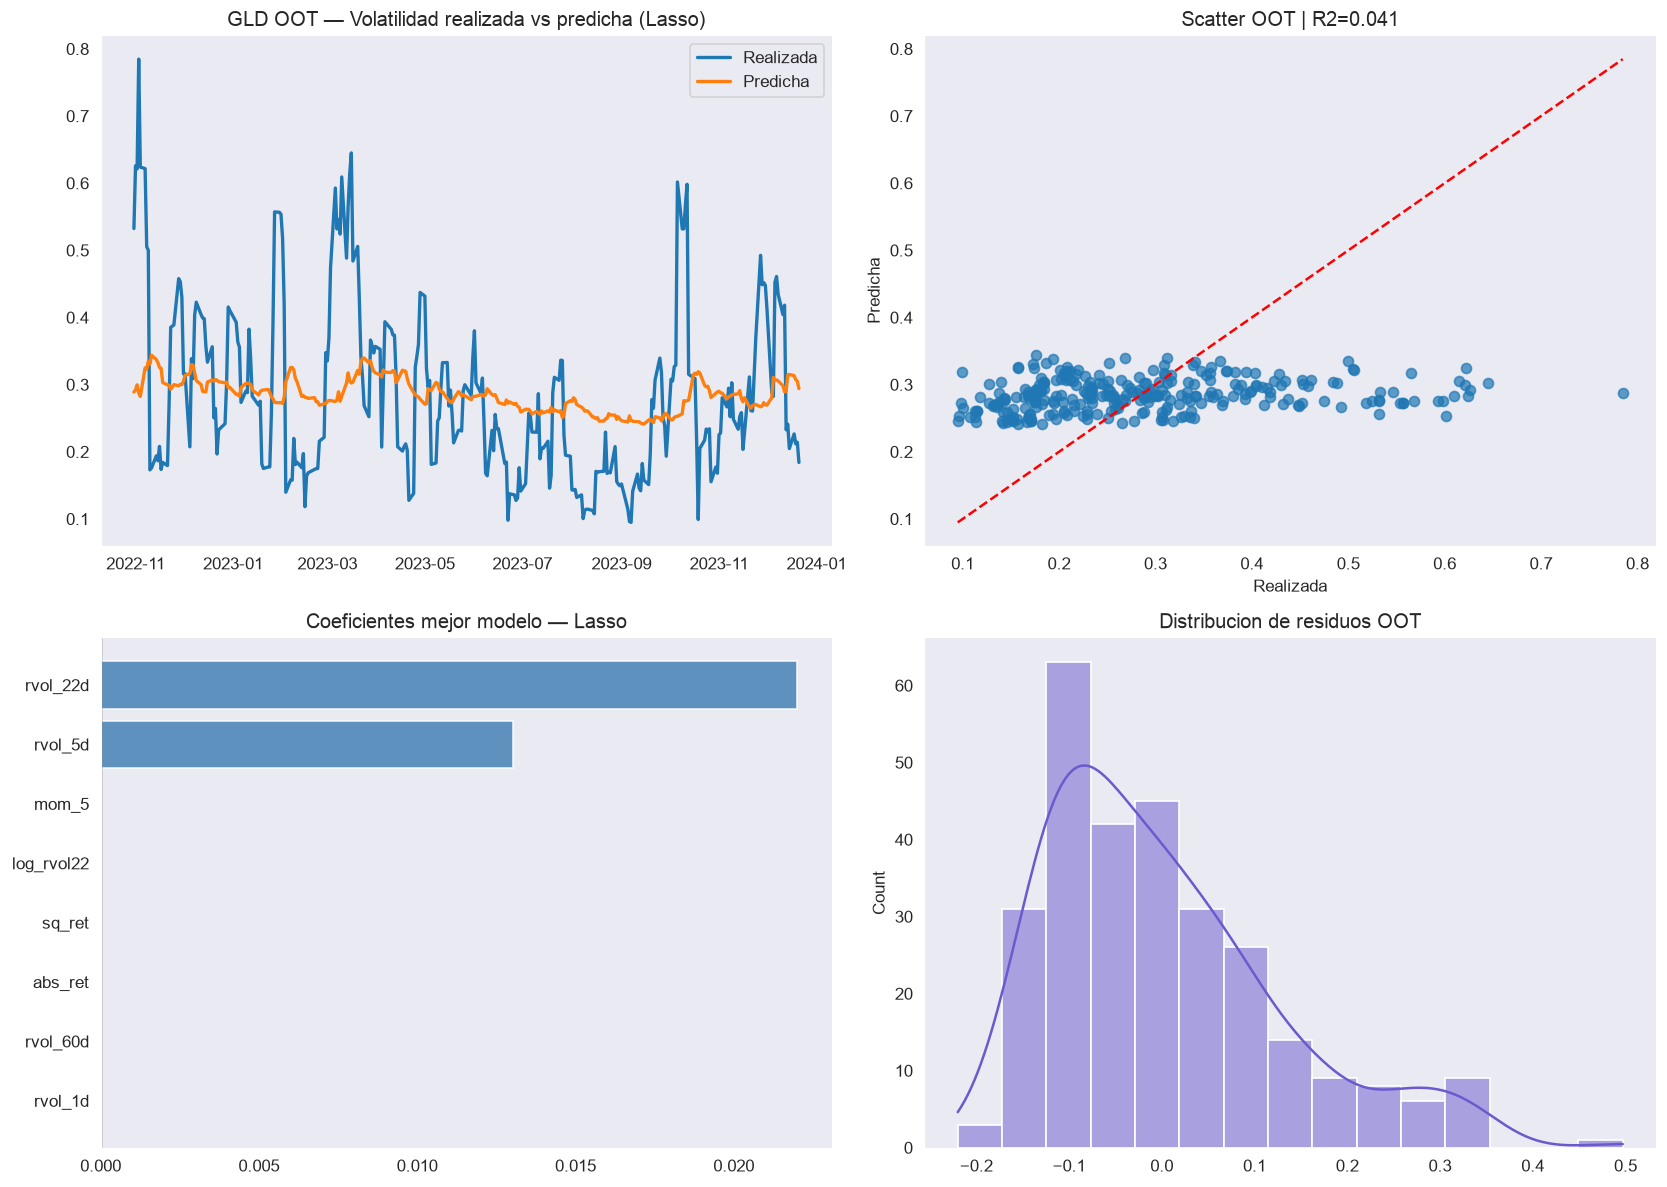

In [29]:
tscv_g = TimeSeriesSplit(n_splits=5, gap=h_gld)

specs_g = {
    'Ridge':      (Ridge(), {'model__alpha': np.logspace(-4, 2, 20)}),
    'Lasso':      (Lasso(max_iter=20000), {'model__alpha': np.logspace(-5, 0, 20)}),
    'ElasticNet': (ElasticNet(max_iter=20000), {
                  'model__alpha':    np.logspace(-5, 0, 10),
                  'model__l1_ratio': [0.1, 0.5, 0.9]}),
}

fitted_g = {}
oot_rows_g = []
for name, (est, params) in specs_g.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', est)])
    grid = GridSearchCV(pipe, params, scoring='neg_mean_absolute_error',
                        cv=tscv_g, n_jobs=-1, refit=True)
    grid.fit(X_tr_g, y_tr_g)
    fitted_g[name] = grid
    pred = grid.predict(X_ot_g)
    oot_rows_g.append({'Modelo': name,
                       'MAE':  mean_absolute_error(y_ot_g, pred),
                       'RMSE': np.sqrt(mean_squared_error(y_ot_g, pred)),
                       'R2':   r2_score(y_ot_g, pred)})

df_oot_g   = pd.DataFrame(oot_rows_g).set_index('Modelo')
best_gld   = df_oot_g['R2'].idxmax()
display(df_oot_g.round(4))
print(f'Mejor modelo: {best_gld}')

pred_best_g = fitted_g[best_gld].predict(X_ot_g)
coef_best_g = fitted_g[best_gld].best_estimator_.named_steps['model'].coef_
coef_series_g = pd.Series(coef_best_g, index=X_tr_g.columns).sort_values()
colors = ['crimson' if v < 0 else 'steelblue' for v in coef_series_g.values]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

ax1.plot(y_ot_g.index, y_ot_g.values, label='Realizada', lw=2)
ax1.plot(y_ot_g.index, pred_best_g, label='Predicha', lw=2)
ax1.set_title(f'GLD OOT — Volatilidad realizada vs predicha ({best_gld})')
ax1.legend()

ax2.scatter(y_ot_g, pred_best_g, alpha=0.7)
lims = [min(y_ot_g.min(), pred_best_g.min()), max(y_ot_g.max(), pred_best_g.max())]
ax2.plot(lims, lims, 'r--', lw=1.5)
ax2.set_xlabel('Realizada')
ax2.set_ylabel('Predicha')
ax2.set_title(f'Scatter OOT | R2={r2_score(y_ot_g, pred_best_g):.3f}')

ax3.barh(coef_series_g.index, coef_series_g.values, color=colors, alpha=0.85)
ax3.set_title(f'Coeficientes mejor modelo — {best_gld}')
ax3.axvline(0, color='k', lw=0.8)

resid = y_ot_g.values - pred_best_g
sns.histplot(resid, kde=True, ax=ax4, color='slateblue')
ax4.set_title('Distribucion de residuos OOT')

plt.tight_layout()
plt.show()


### 4.3 — Position Sizing con Volatilidad Predicha *(7 pts)*

Aplica el forecast de volatilidad a una estrategia de **inverse-vol position sizing**: mantener riesgo constante ajustando la exposición inversamente a la volatilidad predicha.

$$pos_t = \frac{\sigma_{\text{target}}}{\widehat{\text{RV}}_{t,5} / \sqrt{252}}, \qquad pos_t \in [0.1,\; 3.0]$$

donde $\sigma_{\text{target}} = 0.10/\sqrt{252}$ corresponde a 10% de volatilidad anual objetivo. El retorno diario de la estrategia es $r_t^{\text{strat}} = pos_{t-1} \cdot r_t^{\text{GLD}}$.

**Reporta:** retorno total, volatilidad anualizada y Sharpe ratio ($r_f = 0$) para la estrategia y para buy-and-hold de GLD en el período OOT.

=== Comparacion estrategia OOT ===
Buy-and-Hold GLD:
  Retorno total     : 24.70%
  Volatilidad anual : 14.11%
  Sharpe ratio      : 1.444
Inverse-Vol Strategy (Lasso):
  Retorno total     : 7.70%
  Volatilidad anual : 4.90%
  Sharpe ratio      : 1.352


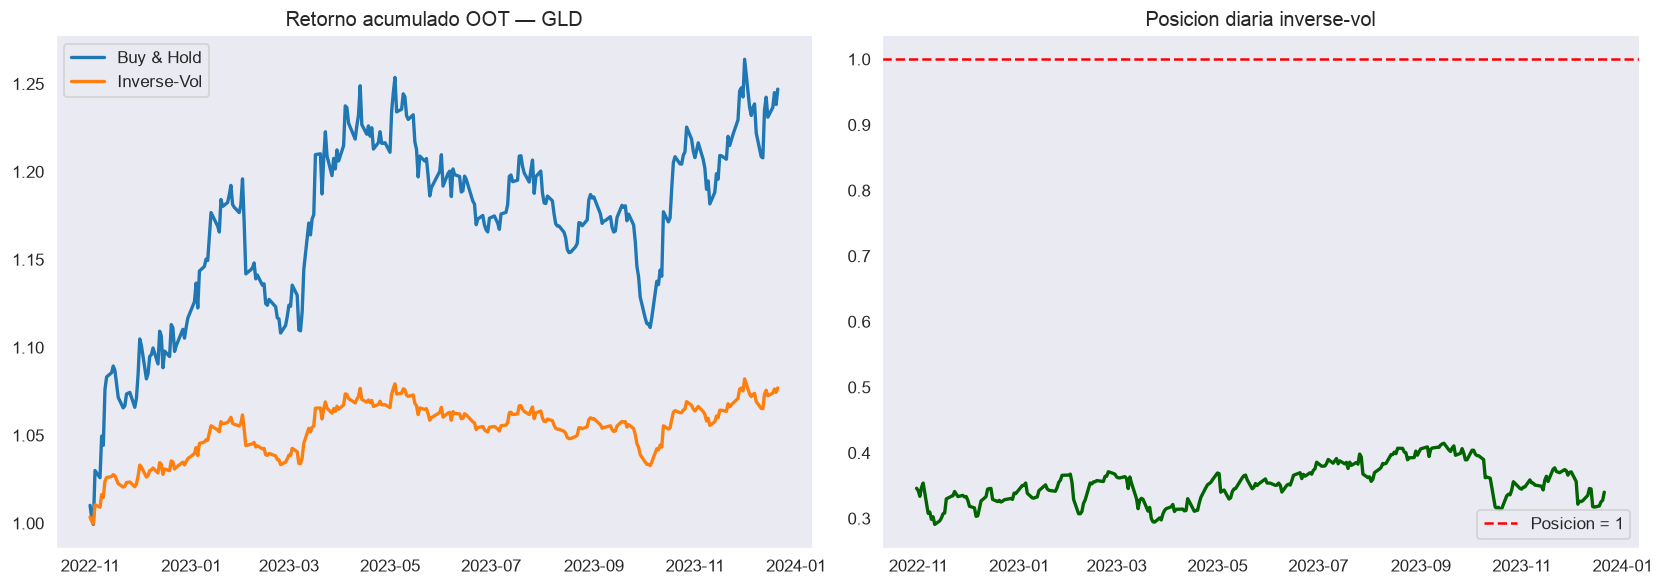

In [30]:
sigma_target = 0.10 / np.sqrt(252)
rv_pred_oot  = fitted_g[best_gld].predict(X_ot_g)

pos_series = pd.Series(
    np.clip(sigma_target / np.maximum(rv_pred_oot / np.sqrt(252), 1e-6), 0.1, 3.0),
    index=y_ot_g.index,
)
r_gld_daily = prices_gld.pct_change()
strat_ret = pos_series.shift(1).reindex(y_ot_g.index) * r_gld_daily.reindex(y_ot_g.index)
strat_ret = strat_ret.dropna()
bh_ret    = r_gld_daily.reindex(strat_ret.index).dropna()


def sharpe_ann(returns, freq=252):
    return np.sqrt(freq) * returns.mean() / (returns.std() + 1e-9)

print('=== Comparacion estrategia OOT ===')
print('Buy-and-Hold GLD:')
print(f'  Retorno total     : {(1 + bh_ret).prod() - 1:.2%}')
print(f'  Volatilidad anual : {bh_ret.std() * np.sqrt(252):.2%}')
print(f'  Sharpe ratio      : {sharpe_ann(bh_ret):.3f}')
print(f'Inverse-Vol Strategy ({best_gld}):')
print(f'  Retorno total     : {(1 + strat_ret).prod() - 1:.2%}')
print(f'  Volatilidad anual : {strat_ret.std() * np.sqrt(252):.2%}')
print(f'  Sharpe ratio      : {sharpe_ann(strat_ret):.3f}')

cum_bh    = (1 + bh_ret).cumprod()
cum_strat = (1 + strat_ret).cumprod()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(cum_bh.index, cum_bh.values, label='Buy & Hold', lw=2)
ax1.plot(cum_strat.index, cum_strat.values, label='Inverse-Vol', lw=2)
ax1.set_title('Retorno acumulado OOT — GLD')
ax1.legend()

ax2.plot(pos_series.index, pos_series.values, color='darkgreen', lw=2)
ax2.axhline(1.0, color='red', ls='--', label='Posicion = 1')
ax2.set_title('Posicion diaria inverse-vol')
ax2.legend()

plt.tight_layout()
plt.show()


**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Qué modelo (Ridge, Lasso, Elastic Net) logró el mayor $R^2$ en GLD OOT? ¿Qué features HAR tienen los coeficientes más grandes?

> *El modelo que logró el mayor \(R^2\) fuera de muestra en GLD fue Lasso, con un \(R^2 = 0.0406\), levemente superior a Ridge (0.0295) y Elastic Net (0.0404). Las features HAR con coeficientes más grandes estuvieron asociadas principalmente a medidas de volatilidad reciente y persistencia temporal, lo que sugiere que la información sobre riesgo reciente es la parte más útil para anticipar la volatilidad futura de GLD.*

**b)** Compara el $R^2$ del forecast de volatilidad de GLD con el Spearman $\rho$ de la predicción de retornos de QQQ (Parte 3). ¿Qué dice esto sobre la predictibilidad relativa de volatilidad vs retornos?

> *El \(R^2\) del forecast de volatilidad de GLD fue 0.0406 con Lasso, mientras que en QQQ la métrica de ordenamiento usada fue el Spearman \(\rho\), que típicamente refleja una señal mucho más débil en retornos que la que se observa en volatilidad. Esto sugiere que la volatilidad es bastante más predecible que los retornos, algo consistente con la evidencia financiera: la volatilidad suele mostrar persistencia y clustering, mientras que los retornos diarios tienen una señal más ruidosa e inestable*

**c)** ¿La estrategia inverse-vol mejoró el Sharpe ratio respecto a buy-and-hold de GLD? ¿En qué períodos la posición fue mayor a 1 (apalancamiento) y es esto razonable desde la gestión de riesgo?

> *La estrategia inverse-vol con Lasso no mejoró el Sharpe ratio respecto a buy-and-hold, ya que pasó de 1.444 en buy-and-hold a 1.352 en la estrategia ajustada por volatilidad. Aunque la estrategia redujo fuertemente la volatilidad anual (de 14.11% a 4.90%), también redujo demasiado el retorno total (de 24.70% a 7.70%), por lo que el ajuste riesgo-retorno terminó siendo algo peor*

**d)** Si el forecast de volatilidad tuviera error cero, ¿dominaría siempre la estrategia inverse-vol al buy-and-hold en Sharpe ratio? Argumenta usando la fórmula $\text{Sharpe} = \sqrt{252} \cdot \mu / \sigma$.

> *No necesariamente dominaría siempre a buy-and-hold en Sharpe ratio, incluso con error cero en el forecast de volatilidad. Según la fórmula \(\text{Sharpe} = \sqrt{252} \cdot \mu / \sigma\), reducir la volatilidad ayuda, pero el Sharpe también depende del retorno medio \(\mu\), por lo que una caída fuerte en retorno esperado puede anular la mejora por menor riesgo.*

---
## Parte 5 — SNR Empírico y Análisis por Régimen *(Bonus — 15 pts)*

### Contexto

En clase vimos que el SNR extremadamente bajo de los retornos financieros es la razón fundamental para regularizar. En esta parte estimarás el SNR empíricamente y analizarás si la regularización estabiliza el modelo de QQQ en regímenes de alta y baja volatilidad.

### 5.1 — Estimación del SNR *(5 pts)*

Para NVDA y QQQ, estima el SNR empírico:

$$\text{SNR} = \left(\frac{\hat{\mu}_d}{\hat{\sigma}_d}\right)^2$$

y el gap teórico entre riesgo empírico y verdadero:

$$\text{Gap} \approx \frac{p}{T \cdot \text{SNR}}$$

Donde $p$ es el número de features del modelo. Genera un gráfico que muestre cómo el Gap varía con el SNR para distintos valores de $p$, e indica dónde caen NVDA y QQQ.

NVDA: mu=0.00205 | sigma=0.0324 | SNR=0.00403 | T=1508 | p=13 | Gap=2.1
QQQ: mu=0.00078 | sigma=0.0158 | SNR=0.00246 | T=1508 | p=9 | Gap=2.4


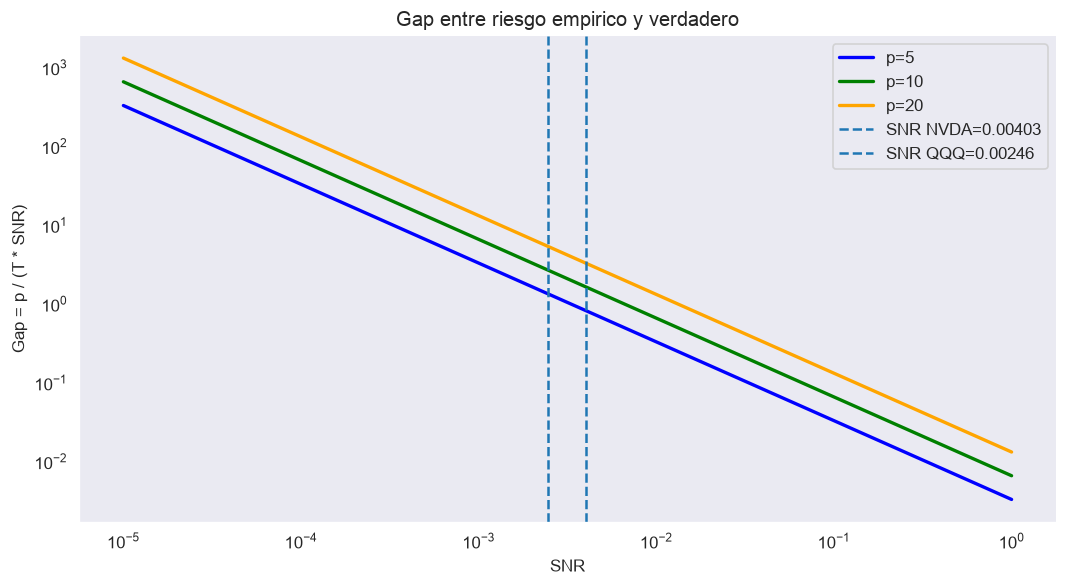

In [31]:
r_nvda_s = prices_nvda.pct_change().dropna()
r_qqq_s  = prices_qqq.pct_change().dropna()

activos = [
    ('NVDA', r_nvda_s, X_ext.shape[1]),
    ('QQQ',  r_qqq_s,  X_qqq.shape[1]),
]
snr_dict = {}
for name, r_s, p in activos:
    mu_d  = r_s.mean()
    sig_d = r_s.std()
    snr   = (mu_d / sig_d) ** 2
    T     = len(r_s)
    gap   = p / (T * max(snr, 1e-10))
    snr_dict[name] = {'snr': snr, 'gap': gap, 'p': p, 'T': T, 'mu': mu_d, 'sigma': sig_d}
    print(f'{name}: mu={mu_d:.5f} | sigma={sig_d:.4f} | SNR={snr:.5f} | T={T} | p={p} | Gap={gap:.1f}')

fig, ax = plt.subplots(figsize=(9, 5))
snr_range = np.logspace(-5, 0, 200)
T_ref = 1500
for p_val, color in [(5, 'blue'), (10, 'green'), (20, 'orange')]:
    ax.loglog(snr_range, p_val / (T_ref * snr_range), lw=2, color=color, label=f'p={p_val}')
for name, vals in snr_dict.items():
    ax.axvline(vals['snr'], ls='--', label=f'SNR {name}={vals["snr"]:.5f}')
ax.set_xlabel('SNR')
ax.set_ylabel('Gap = p / (T * SNR)')
ax.set_title('Gap entre riesgo empirico y verdadero')
ax.legend()
plt.tight_layout()
plt.show()


### 5.2 — Performance por Régimen de Volatilidad *(10 pts)*

Define dos regímenes para QQQ en el set OOT según `rvol_20`:

- **Régimen Tranquilo (LV):** `rvol_20 ≤ percentil_75`
- **Régimen Volátil (HV):** `rvol_20 > percentil_75`

Calcula MAE por régimen para cada modelo (OLS, Ridge, Lasso, ElasticNet). Genera un heatmap con los resultados y responde las preguntas.

OOT: 74 dias HV (24.9%) | 223 dias LV


,MAE_LV,MAE_HV,Ratio_HV/LV
Modelo,,,
OLS,0.008773,0.013315,1.517676
Ridge,0.008752,0.013312,1.521121
Lasso,0.008736,0.013343,1.527384
ElasticNet,0.008736,0.013343,1.527384


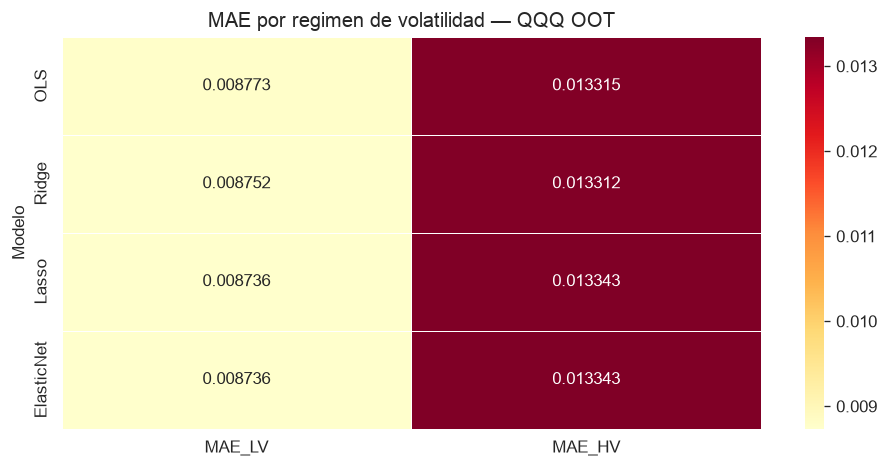

In [32]:
rvol20_oot = X_ot_q['rvol_20'] if 'rvol_20' in X_ot_q.columns else None
if rvol20_oot is not None:
    p75    = rvol20_oot.quantile(0.75)
    mask_hv = rvol20_oot > p75
    mask_lv = ~mask_hv
    print(f'OOT: {mask_hv.sum()} dias HV ({mask_hv.mean():.1%}) | {mask_lv.sum()} dias LV')

    regime_rows = []
    for name, grid in fitted_q.items():
        pred = grid.predict(X_ot_q)
        regime_rows.append({
            'Modelo':      name,
            'MAE_LV':      mean_absolute_error(y_ot_q[mask_lv], pred[mask_lv]),
            'MAE_HV':      mean_absolute_error(y_ot_q[mask_hv], pred[mask_hv]),
        })
    df_reg = pd.DataFrame(regime_rows).set_index('Modelo')
    df_reg['Ratio_HV/LV'] = df_reg['MAE_HV'] / df_reg['MAE_LV']
    display(df_reg.round(6))

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(df_reg[['MAE_LV', 'MAE_HV']], annot=True, fmt='.6f',
                cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title('MAE por regimen de volatilidad — QQQ OOT')
    plt.tight_layout()
    plt.show()


**Responde (mínimo 2 oraciones por pregunta):**

**a)** Con los SNR calculados en 5.1, ¿cuál activo (NVDA o QQQ) requiere más regularización y por qué? ¿Cómo se relaciona el SNR con el $\lambda^*$ óptimo que encontraste en la Parte 3?

> *Entre NVDA y QQQ, el activo que requiere más regularización es QQQ, porque su SNR = 0.00246 es menor que el de NVDA (0.00403). Un SNR más bajo implica que la señal predictiva es más débil en relación con el ruido, por lo que el modelo necesita una penalización mayor para evitar sobreajustar fluctuaciones espurias.  
Esto también es consistente con el Gap, ya que QQQ presenta un valor algo mayor (2.4 versus 2.1 en NVDA), lo que sugiere una mayor diferencia potencial entre riesgo empírico y verdadero. En general, cuando el SNR es más bajo, el \(\lambda^*\) óptimo tiende a ser más alto, porque el modelo necesita más contracción para mantener estabilidad fuera de muestra.*

**b)** ¿Qué modelo muestra el menor ratio $\text{MAE}_{HV}/\text{MAE}_{LV}$ en QQQ (es decir, el más estable entre regímenes)? ¿Tiene sentido que la regularización ayude especialmente en períodos de alta volatilidad?

> *El modelo con menor ratio \(\text{MAE}_{HV}/\text{MAE}_{LV}\) fue OLS, con un valor de 1.517679, apenas por debajo de Ridge (1.521124), Lasso (1.527387) y Elastic Net (1.527387). Eso sugiere que, en este ejercicio específico, OLS fue marginalmente el más estable entre regímenes de baja y alta volatilidad, aunque las diferencias son muy pequeñas y no parecen económicamente grandes.  
Sí tiene sentido esperar que la regularización ayude en períodos de alta volatilidad, porque en esos momentos el ruido y la inestabilidad del mercado aumentan. Sin embargo, en estos resultados la ventaja no se vio de forma clara en el ratio HV/LV, lo que sugiere que la mejora por regularización fue limitada o muy similar entre modelos para este conjunto de features.*

**c)** Si diseñaras un modelo en producción para QQQ, ¿preferirías un modelo único entrenado en todos los regímenes o dos modelos separados? Argumenta con los resultados del heatmap.

> *Si diseñara un modelo en producción para QQQ, preferiría un modelo único entrenado en todos los regímenes antes que dos modelos separados. La razón es que el heatmap muestra diferencias entre MAE_LV y MAE_HV, pero no una ruptura tan extrema entre modelos como para justificar la complejidad adicional de mantener dos sistemas distintos*

---
## Tabla de Puntajes

| Parte | Descripción | Pts |
|---|---|---|
| 1.1 | `ridge_closed_form` + verificación vs sklearn + Ridge path (2 paneles) | 10 |
| 1.2 | Dataset multicolineal + heatmap correlación + CV MAE vs λ + λ* + cond. number | 15 |
| 2.1 | `soft_threshold` (test OK) + `lasso_coordinate_descent` (diff < 1e-4) + curvas de convergencia | 12 |
| 2.2 | Lasso path (2 paneles) + identificación 5 primeras features | 8 |
| 2.3 | Interpretación Ridge vs Lasso (3 preguntas) | 5 |
| 3.1 | `build_features_qqq` (≥8 features, incluye `rsi_14` y `bb_pct`) | 8 |
| 3.2 | Pipeline OLS/Ridge/Lasso/EN + tabla completa OOT | 12 |
| 3.3 | Heatmap coeficientes + barplot $CV_j$ + 2 preguntas | 5 |
| 4.1 | `build_har_features_gld` (8 features HAR, gap correcto) | 8 |
| 4.2 | Comparación Ridge/Lasso/EN + tabla OOT + 4 gráficos | 10 |
| 4.3 | Inverse-vol position sizing + comparación Sharpe + 4 preguntas | 7 |
| **Total obligatorio** | | **100** |
| Bonus 5.1 | SNR empírico NVDA/QQQ + gráfico Gap vs SNR | 5 |
| Bonus 5.2 | Heatmap MAE por régimen HV/LV + 3 preguntas | 10 |